In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\santu\OneDrive\Desktop\customer_data.csv")
print(df.head())

  Customer_ID  Age  Gender  Annual_Income  Spending_Score
0        C001   25    Male          30000              60
1        C002   40  Female          60000              40
2        C003   35    Male          80000              80
3        C004   23  Female          20000              70
4        C005   52    Male          90000              20


In [3]:
def segment(row):
    if row['Annual_Income'] > 70000 and row['Spending_Score'] > 70:
        return "High Value"
    elif row['Annual_Income'] > 70000:
        return "Rich but Low Spending"
    elif row['Spending_Score'] > 70:
        return "Potential Customers"
    else:
        return "Low Value"

df['Segment'] = df.apply(segment, axis=1)

In [4]:
print(df)

  Customer_ID  Age  Gender  Annual_Income  Spending_Score  \
0        C001   25    Male          30000              60   
1        C002   40  Female          60000              40   
2        C003   35    Male          80000              80   
3        C004   23  Female          20000              70   
4        C005   52    Male          90000              20   
5        C006   30  Female          75000              85   
6        C007   28    Male          40000              50   
7        C008   45  Female          65000              30   
8        C009   33    Male          70000              75   
9        C010   27  Female          50000              65   

                 Segment  
0              Low Value  
1              Low Value  
2             High Value  
3              Low Value  
4  Rich but Low Spending  
5             High Value  
6              Low Value  
7              Low Value  
8    Potential Customers  
9              Low Value  


In [5]:
df['Segment'].value_counts()

Segment
Low Value                6
High Value               2
Rich but Low Spending    1
Potential Customers      1
Name: count, dtype: int64

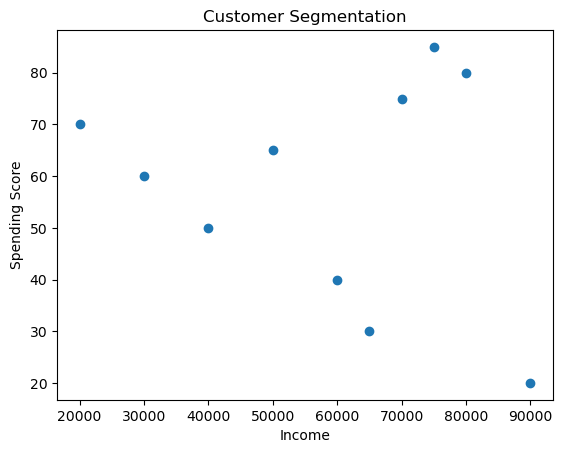

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

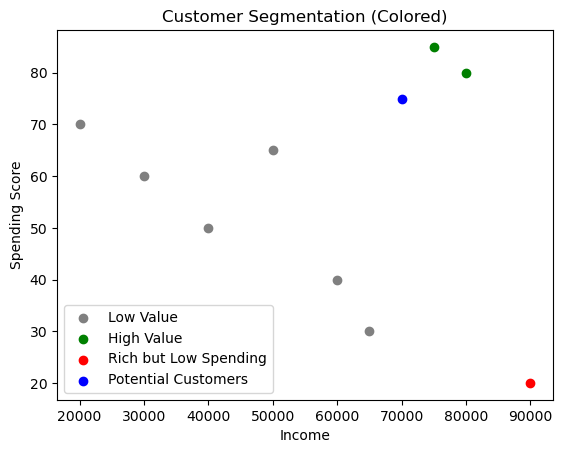

In [7]:
import matplotlib.pyplot as plt

colors = {
    "High Value": "green",
    "Potential Customers": "blue",
    "Rich but Low Spending": "red",
    "Low Value": "gray"
}

plt.figure()

for segment in df['Segment'].unique():
    subset = df[df['Segment'] == segment]
    plt.scatter(subset['Annual_Income'], subset['Spending_Score'],
                label=segment,
                color=colors[segment])

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (Colored)")
plt.legend()
plt.show()

In [8]:
from sklearn.cluster import KMeans

X = df[['Annual_Income', 'Spending_Score']]

kmeans = KMeans(n_clusters=4, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

C:\Users\santu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


In [13]:
from sklearn.cluster import KMeans
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans

In [14]:
df['Cluster'].value_counts()

Cluster
0    4
2    3
1    2
3    1
Name: count, dtype: int64

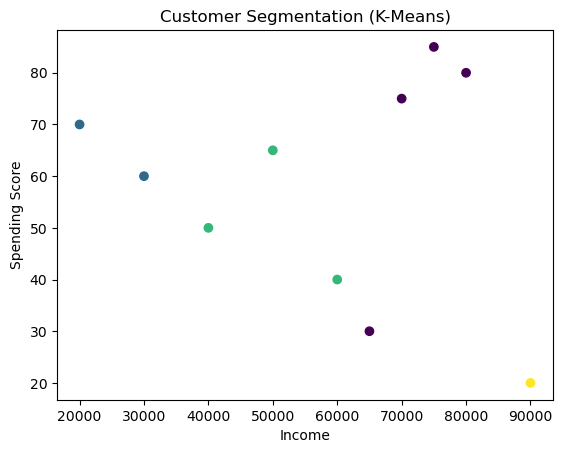

In [16]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (K-Means)")
plt.show()

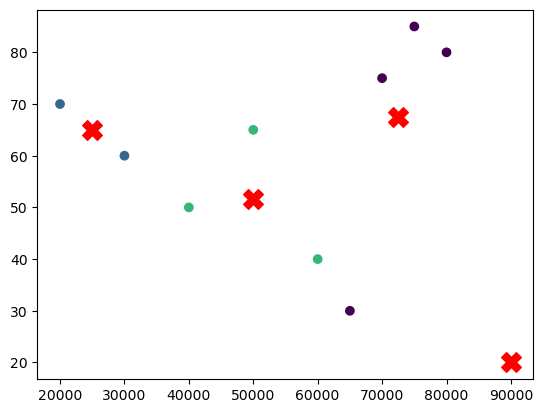

In [17]:
centroids = kmeans.cluster_centers_

plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
plt.show()